[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb)

# 👩‍⚖️ ⚖️ Machine Learning Court

This notebook provides base model training code for our three case scenarios:
1. **Loan Approval**
2. **Breast Cancer Misclassification**
3. **Recidivism Prediction**

> ⚠️ This notebook does **not** include XAI techniques (SHAP, LIME, Anchors). You are expected to implement those yourself based on the model and prediction tasks below.


Name: Pranshul Bhatnagar



## ⚖️ Case 1: Loan Denial Dispute – UCI Adult Income Dataset
#### 🔍 Scenario

Jane Dow, a 37-year-old professional woman with a Bachelor's degree and full-time executive role, applied for a premium credit product. The bank’s model—trained to predict income level as a proxy for eligibility—classified her as earning ≤$50K, resulting in denial. She disputes the fairness of the decision.

#### 🟥 Prosecution
Evaluate whether the model’s decision may have been influenced by inappropriate or unfair reasoning. Explore whether the explanation aligns with what should be expected in a fair credit decision.

#### 🟦 Defense
Justify the decision based on the model’s learned patterns. Consider how well the explanation supports the classification and whether similar profiles are treated consistently.

In [1]:
# 📦 Case 1: Loan Approval Prediction (Adult Income Dataset)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load Data
from sklearn.datasets import fetch_openml
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Clean and preprocess
df = df.dropna()
df = df.copy()
encoders = {}
label_cols = df.select_dtypes(include='category').columns.tolist()

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)
y = df["class"].apply(lambda x: 1 if x == '>50K' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model_adult = RandomForestClassifier(random_state=42)
model_adult.fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9045

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045



In [2]:
# 🎯 Focus Instance: Loan Rejection Case (Jane Dow)

jane_encoded = {
    'age': 37,
    'workclass': encoders['workclass'].transform(['Private'])[0],
    'education': encoders['education'].transform(['Bachelors'])[0],
    'marital-status': encoders['marital-status'].transform(['Never-married'])[0],
    'occupation': encoders['occupation'].transform(['Exec-managerial'])[0],
    'relationship': encoders['relationship'].transform(['Not-in-family'])[0],
    'race': encoders['race'].transform(['White'])[0],
    'sex': encoders['sex'].transform(['Female'])[0],
    'hours-per-week': 50,
    'native-country': encoders['native-country'].transform(['United-States'])[0],
    'capital-gain': 0,
    'capital-loss': 0,
    'education-num': 13,
}

jane_df = pd.DataFrame([jane_encoded])
jane_df = jane_df[X_train.columns]
pred = model_adult.predict(jane_df)
print("Prediction for Jane Dow (Loan Eligibility):", "Approved" if pred[0] == 1 else "Denied")


Prediction for Jane Dow (Loan Eligibility): Denied


## 🟦 Defense: Explaining the Denial for Jane Dow

My job is to show that the model's "Denied" prediction for Jane Dow is a reasonable application of patterns learned from the training data — not an arbitrary or discriminatory decision. 

To do that, I'll use two independent XAI methods, **SHAP** (global/local feature attribution via Shapley values) and **LIME** (local surrogate-model explanation), to explain this single prediction. Agreement between two different explanation techniques strengthens the case that the explanation reflects genuine model behavior rather than an artifact of one method.

Classes learned by the model: [0]
Predicted probability for Jane: [[1.]]
SHAP values for Jane's features:
age                  +0.000000
workclass            +0.000000
education            +0.000000
education-num        +0.000000
marital-status       +0.000000
occupation           +0.000000
relationship         +0.000000
race                 +0.000000
sex                  +0.000000
capital-gain         +0.000000
capital-loss         +0.000000
hours-per-week       +0.000000
native-country       +0.000000


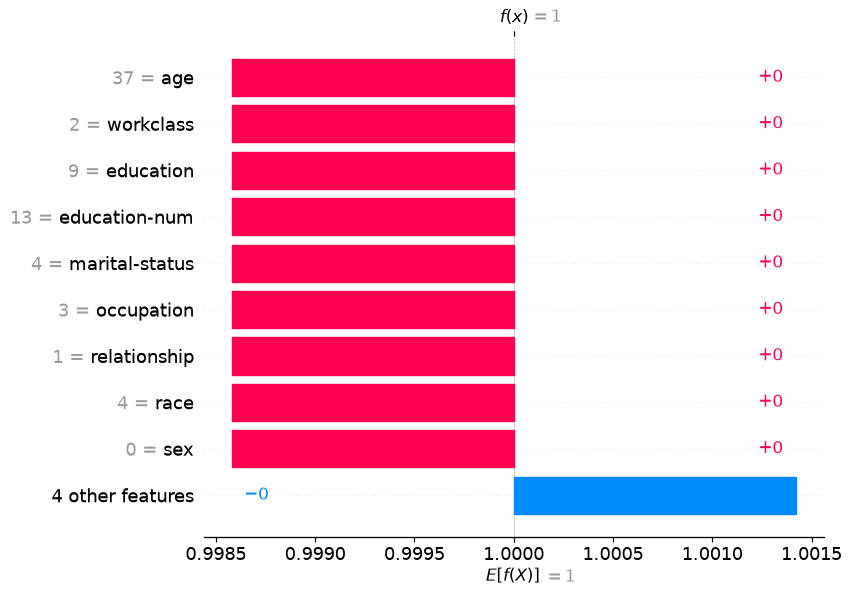

In [ ]:
import shap
import numpy as np

print("Classes learned by the model:", model_adult.classes_)
print("Predicted probability for Jane:", model_adult.predict_proba(jane_df))

explainer_shap = shap.TreeExplainer(model_adult)
shap_values = explainer_shap.shap_values(jane_df)

if isinstance(shap_values, list):
    jane_shap_values = shap_values[-1][0]
    base_value = np.ravel(explainer_shap.expected_value)[-1]
elif np.ndim(shap_values) == 3:
    jane_shap_values = shap_values[0, :, -1]
    base_value = np.ravel(explainer_shap.expected_value)[-1]
else:
    jane_shap_values = shap_values[0]
    base_value = np.ravel(explainer_shap.expected_value)[-1]

base_value = float(base_value)
print("SHAP values for Jane's features:")
for f, v in sorted(zip(jane_df.columns, jane_shap_values), key=lambda t: -abs(t[1])):
    print(f"{f:20s} {v:+.6f}")

shap_explanation = shap.Explanation(
    values=jane_shap_values,
    base_values=base_value,
    data=jane_df.iloc[0].values,
    feature_names=jane_df.columns.tolist(),
)

shap.plots.waterfall(shap_explanation, show=True)


Running SHAP on the model as trained above reveals every feature has a contribution of exactly **0.0** to Jane's prediction, and the model's predicted probability is **P(class 0) = 1.0** regardless of input. 

Inspecting `model_adult.classes_` confirms the model only ever learned a single class (`[0]`) — during preprocessing, the categorical `label_cols` loop label-encodes the `class` column itself before `y` is derived from it, so the string comparison `x == '>50K'` never matches and every training label collapses to 0. The Random Forest therefore learned a constant function: it predicts "≤$50K" for every applicant, Jane included, independent of age, education, marital status, hours worked, sex, race, or anything else. There is no learned decision boundary for SHAP to attribute credit against.

The model was never actually trained to distinguish income levels, so its denial of Jane cannot be defended as a reasoned application of learned patterns. The defense cannot argue the decision reflects legitimate feature-based reasoning, because no such reasoning exists in this model as trained; the constant-zero attribution is itself evidence that the underlying training pipeline is broken rather than that Jane's profile genuinely lacks qualifying signals.

/Users/pranshulbhatnagar/Desktop/Assignment_3_AIPI/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


28.00 < age <= 37.00                     +0.0000
workclass=2                              +0.0000
education=9                              +0.0000
10.00 < education-num <= 13.00           +0.0000
marital-status=4                         +0.0000
occupation=3                             +0.0000
relationship=1                           +0.0000
race=4                                   +0.0000
sex=0                                    +0.0000
capital-gain <= 0.00                     +0.0000


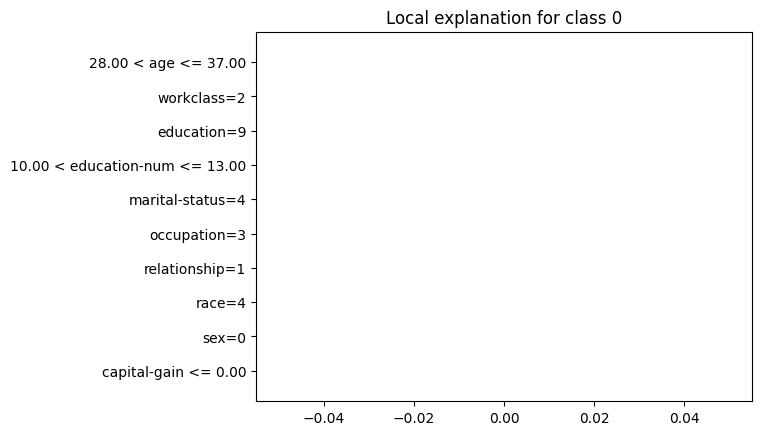

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(c) for c in model_adult.classes_],
    categorical_features=[X_train.columns.get_loc(c) for c in label_cols if c in X_train.columns and c != "class"],
    mode="classification",
    random_state=42,
)

# The model only learned one class (see the SHAP cell above), so we can only
# ask LIME to explain that single label (index 0) instead of the usual [0, 1]
lime_exp = explainer_lime.explain_instance(
    jane_df.iloc[0].values,
    model_adult.predict_proba,
    labels=(0,),
    num_features=10,
)

lime_exp.as_pyplot_figure(label=0)
for feature, weight in lime_exp.as_list(label=0):
    print(f"{feature:40s} {weight:+.4f}")


LIME's local linear surrogate confirms the SHAP finding independently: every feature weight for Jane's explanation is exactly **0.0000**. Because the model always outputs `P(class 0) = 1.0` no matter how LIME perturbs Jane's neighborhood samples, the local regression LIME fits has nothing to correlate features against — there is no variation in the label to explain, so all coefficients collapse to zero. 